In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pd.read_csv('seattle-weather.csv')

In [3]:
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
data.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [5]:
data.describe([0.01,0.1,0.25,0.5,0.75,0.9,0.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
precipitation,1461.0,3.029432,6.680194,0.0,0.00,0.0,0.0,0.0,2.8,9.9,32.38,55.9
temp_max,1461.0,16.439083,7.349758,-1.6,2.56,7.2,10.6,15.6,22.2,26.7,33.30,35.6
temp_min,1461.0,8.234771,5.023004,-7.1,-3.24,1.7,4.4,8.3,12.2,14.4,17.44,18.3
wind,1461.0,3.241136,1.437825,0.4,0.86,1.7,2.2,3.0,4.0,5.2,7.54,9.5


In [6]:
train_set = data.iloc[:,2:3].values

In [7]:
#scaler = MinMaxScaler(feature_range=(0,1))
#train_set_scaled = scaler.fit_transform(train_set)

In [8]:
#train_set_scaled

In [9]:
def data_to_xy(train_set,window_size = 10):
    x_train = []
    y_train = []
    for i in range(window_size,len(train_set)):
        x_train.append(train_set[i-10:i,0])
        y_train.append(train_set[i,0])
    x_train,y_train = np.array(x_train),np.array(y_train)
    return x_train,y_train

In [10]:
window = 10
x,y = data_to_xy(train_set,window)

In [11]:
print(len(x),len(y))

1451 1451


In [12]:
x_train = x[:800]
y_train = y[:800]
x_val = x[800:1000]
y_val = y[800:1000]
x_test = x[1000:]
y_test = y[1000:]

In [13]:
x_train.shape

(800, 10)

In [14]:
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_val = np.reshape(x_val,(x_val.shape[0],x_val.shape[1],1))
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

In [16]:
class weather(nn.Module):
    def __init__(self,input_dim=1,hidden_size=50,dropout_p=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_size,
            batch_first=True
    
        )
        self.drop1 = nn.Dropout(dropout_p)
        self.lstm2 = nn.LSTM(
            input_size = hidden_size,
            hidden_size = hidden_size,
            batch_first=True
        )
        self.drop2 = nn.Dropout(dropout_p)
        

      
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x : [batch_size, seq_len, input_dim]

        out, _ = self.lstm1(x)        # [B, T, 50]
        out = self.drop1(out)

        out, _ = self.lstm2(out)      # [B, T, 50]
        out = self.drop2(out)

        last_timestep = out[:, -1, :]  # [B, 50]

        y_hat = self.fc(last_timestep)  # [B, 1]
        return y_hat


In [17]:
from torch.utils.data import TensorDataset,DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
device

device(type='cpu')

In [19]:
x_train_t = torch.from_numpy(x_train).float()
y_train_t = torch.from_numpy(y_train).float()
x_val_t = torch.from_numpy(x_val).float()
y_val_t = torch.from_numpy(y_val).float()

In [20]:
train_ds = TensorDataset(x_train_t,y_train_t)
val_ds = TensorDataset(x_val_t,y_val_t)
batch_size = 32

In [21]:
train_loader = DataLoader(train_ds,batch_size = batch_size,shuffle=True)
val_loader = DataLoader(val_ds,batch_size = batch_size,shuffle=False)

In [22]:
model = weather()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.005)

In [23]:
epoches = 100

for epoch in range(epoches):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    for xb,yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).unsqueeze(1)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds,yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
        train_count += xb.size(0)
    avg_train_loss = train_loss_sum / train_count
    
    model.eval()
    val_loss_sum=0.0
    val_count = 0
    with torch.no_grad():
        for x,y in val_loader:
            xb = x.to(device)
            yb = y.to(device).unsqueeze(1)
            preds = model(x)
            loss = criterion(preds,y)
            val_loss_sum += loss.item() * x.size(0)
            val_count += x.size(0)
        avg_val_loss = val_loss_sum/val_count
    print(f"Epoch {epoch+1:03d}" 
          f" |train_loss = {avg_train_loss:.4f}"
          f" |val_loss = {avg_val_loss:.4f}")

/opt/miniconda3/envs/dl/lib/python3.11/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/miniconda3/envs/dl/lib/python3.11/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 001 |train_loss = 163.6916 |val_loss = 190.4555
Epoch 002 |train_loss = 66.4189 |val_loss = 94.2795
Epoch 003 |train_loss = 54.2751 |val_loss = 72.6152
Epoch 004 |train_loss = 53.3056 |val_loss = 74.3001
Epoch 005 |train_loss = 54.3287 |val_loss = 76.1533
Epoch 006 |train_loss = 53.3870 |val_loss = 74.5667
Epoch 007 |train_loss = 53.9502 |val_loss = 75.9373
Epoch 008 |train_loss = 53.9224 |val_loss = 76.8703
Epoch 009 |train_loss = 53.7804 |val_loss = 77.6463
Epoch 010 |train_loss = 54.4763 |val_loss = 73.0886
Epoch 011 |train_loss = 54.4437 |val_loss = 78.5639
Epoch 012 |train_loss = 53.1295 |val_loss = 74.5776
Epoch 013 |train_loss = 54.3690 |val_loss = 78.3915
Epoch 014 |train_loss = 54.6297 |val_loss = 75.4659
Epoch 015 |train_loss = 53.0665 |val_loss = 78.7466
Epoch 016 |train_loss = 54.0417 |val_loss = 75.6380
Epoch 017 |train_loss = 54.0293 |val_loss = 74.3400
Epoch 018 |train_loss = 54.5465 |val_loss = 74.9661
Epoch 019 |train_loss = 53.7558 |val_loss = 75.8003
Epoch 020 

In [24]:
print("xb shape:", xb.shape)   # 期待 [batch, seq_len, 1]
print("yb shape:", yb.shape)   # 期待 [batch, 1]
print("y example:", yb[:5])

xb shape: torch.Size([8, 10, 1])
yb shape: torch.Size([8, 1])
y example: tensor([[16.7000],
        [19.4000],
        [18.3000],
        [19.4000],
        [22.2000]])


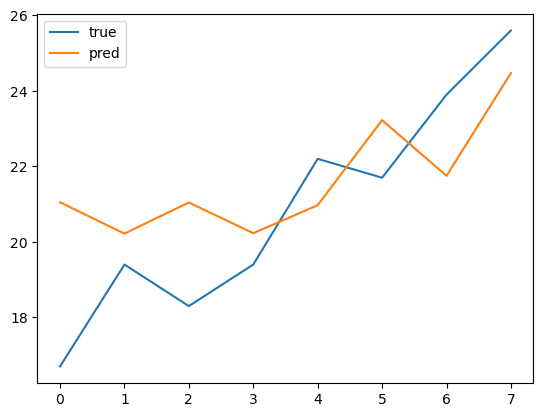

In [25]:
import matplotlib.pyplot as plt
plt.plot(yb[:50], label="true")
plt.plot(preds[:50], label="pred")
plt.legend()
plt.show()

In [26]:
print("train mean:", y_train.mean())
print("pred mean :", preds.mean())

train mean: 15.182625
pred mean : tensor(21.6200)
